## Load notebook

### Python modules

In [1]:
# standard libs
import numpy as np
import pandas as pd
from scipy import sparse
import lmfit as lm
from tqdm import tqdm
import io, sys, importlib
from contextlib import redirect_stdout
import warnings
warnings.filterwarnings("ignore", message="Using UFloat objects with std_dev==0*")


# matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18

# XPCS library
sys.path.append('./XPCSlibrary/')

import ID10tools as ID10
from ID10tools import Nx, Ny, Npx
importlib.reload(ID10)
ID10.set_version('v2')

import XPCStools as XPCS
from XPCStools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAYtools as COSMIC
importlib.reload(COSMIC)
COSMIC.set_beamline('ID10')

#### EXPERIMENTAL VARIABLES ####
XPCS.set_expvar(1350, 1350, 7.1)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000
################################

###### FOLDER PATHS ######
from folder_paths import *
##########################

### Functions

In [2]:
def MTplotfit_byQ_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True):

    print("Using Global variables: model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan\n")    
    global model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan

    if t1_fit is None: t1_fit = 0
    if t2_fit is None: t2_fit = 1e100
    
    g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])

    # DATA PLOTS
    fig, ax = plt.subplots(figsize=(10,5))
    for i, q in enumerate(g2mt.keys()):

        # FIT DATA
        # time-mask 4 fitting
        tmask = (t1_fit<g2mt[q][0])*(g2mt[q][0]<t2_fit)
        x, y, dy =  g2mt[q][0][tmask], g2mt[q][1][tmask], g2mt[q][2][tmask]

        # compute and save the fit
        fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
        g2fit.loc[i] = [q, dQ_section,
                        fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                        fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                        fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                        fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                        fit.redchi,]
        
        # PLOT FIT
        ax.errorbar(g2mt[q][0], g2mt[q][1], yerr=g2mt[q][2], fmt = 'o', c='C'+str(i), label =f'Q = {q} $\\AA^{-1}$')
        xfit = np.arange(np.min(g2mt[q][0]), np.max(g2mt[q][0]), 1e-2)
        yfit = fit.eval(t=xfit)
        ax.plot(xfit, yfit, c='C'+str(i), linestyle='--')

    if t1_fit!=0:     plt.axvline(t1_fit, color='red', linestyle='--')
    if t2_fit!=1e100: plt.axvline(t2_fit, color='red', linestyle='--')
    ax.set_xlabel('t [s]')
    ax.set_ylabel('g2')
    ax.set_xscale('log')
    
    if save: g2fit.to_csv(f"{g2fit4damaged_vGeO2_folder}g2fit-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Qs_section[0]}:{Qs_section[-1]}-dQ={dQ_section}.txt", index=False)
    display(g2fit)

    return g2fit, fig, ax

def plotfitparams_byQ_4damaged_vGeO2(g2fit):
    print("Using Global variables: sample_name, Ndataset, Nscan \n")
    global sample_name, Ndataset, Nscan

    fig, axs = plt.subplots(2, 2, figsize=(14, 8))

    # tau
    axs[0, 0].errorbar(g2fit.Q, g2fit.tau, yerr=g2fit.dtau, fmt='o')
    axs[1, 1].set_xlabel('Q [1/$\\AA$]')
    axs[0, 0].set_ylabel('tau [s]')

    # beta
    axs[0, 1].errorbar(g2fit.Q, g2fit.beta, yerr=g2fit.dbeta, fmt='o')
    axs[1, 1].set_xlabel('Q [1/$\\AA$]')
    axs[0, 1].set_ylabel('beta')

    # c
    axs[1, 0].errorbar(g2fit.Q, g2fit.c, yerr=g2fit.dc, fmt='o')
    axs[1, 1].set_xlabel('Q [1/$\\AA$]')
    axs[1, 0].set_ylabel('c')

    # y0
    axs[1, 1].errorbar(g2fit.Q, g2fit.y0, yerr=g2fit.dy0, fmt='o')
    axs[1, 1].set_xlabel('Q [1/$\\AA$]')
    axs[1, 1].set_ylabel('y0')

    return fig, axs

### Load masks

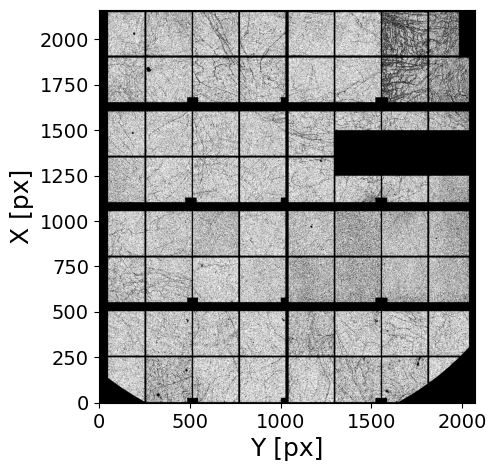

In [3]:
### e4m MASKS
e4m_htmask_GeO2_7_30C  = np.load(MASKS_folder+'e4m_htmask-GeO2_7_30C_0003_0003' +'.npy')
e4m_htmask_GeO2_7_100C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_100C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_170C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_170C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_240C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_240C_0001_0003'+'.npy')
e4m_htmask = e4m_htmask_GeO2_7_30C * e4m_htmask_GeO2_7_100C * e4m_htmask_GeO2_7_170C * e4m_htmask_GeO2_7_240C

e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask*e4m_htmask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.tight_layout(); plt.show()

## XPCS scan: delcoup=1.75, T=730, 30min @ 1ms ON damaged point (GeO2_3_730C, dataset 1, scan 4)

In [4]:
#######################################
sample_name = 'GeO2_3_730C'
Ndataset = 1
Nscan = 4
Nfi, Nff = None, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=60)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 33.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00012.h5 (13/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00021.h5 (22/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00017.h5 (18/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00025

### Qmask

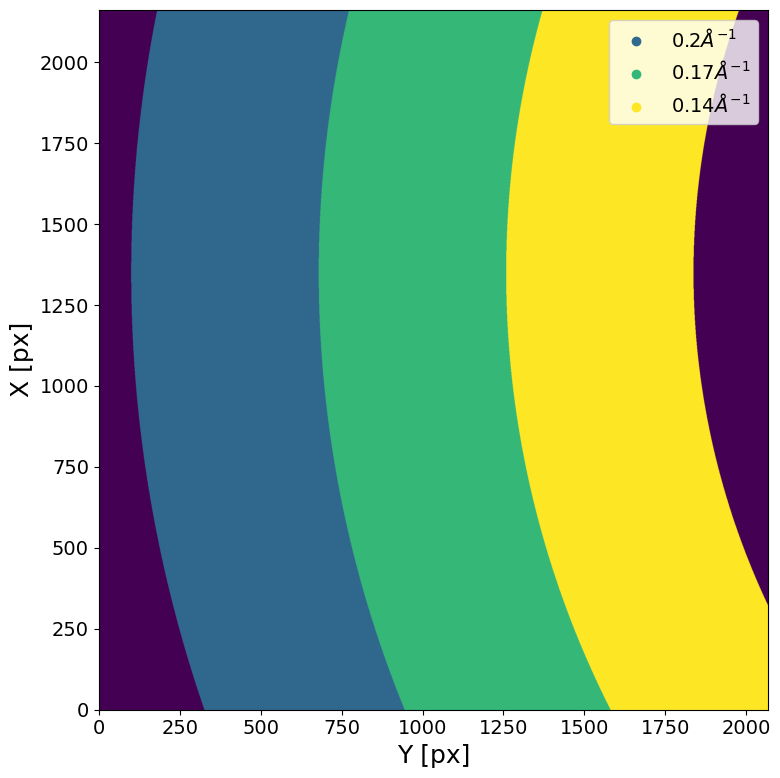

In [5]:
###################
Qs_section = [.2, .17, .14]
dQ_section = .015
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Qs_section, dQ_section, Qmap_plot=False)

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  169024 pixels (of 4471016 => 3.78 %)
################################################################################



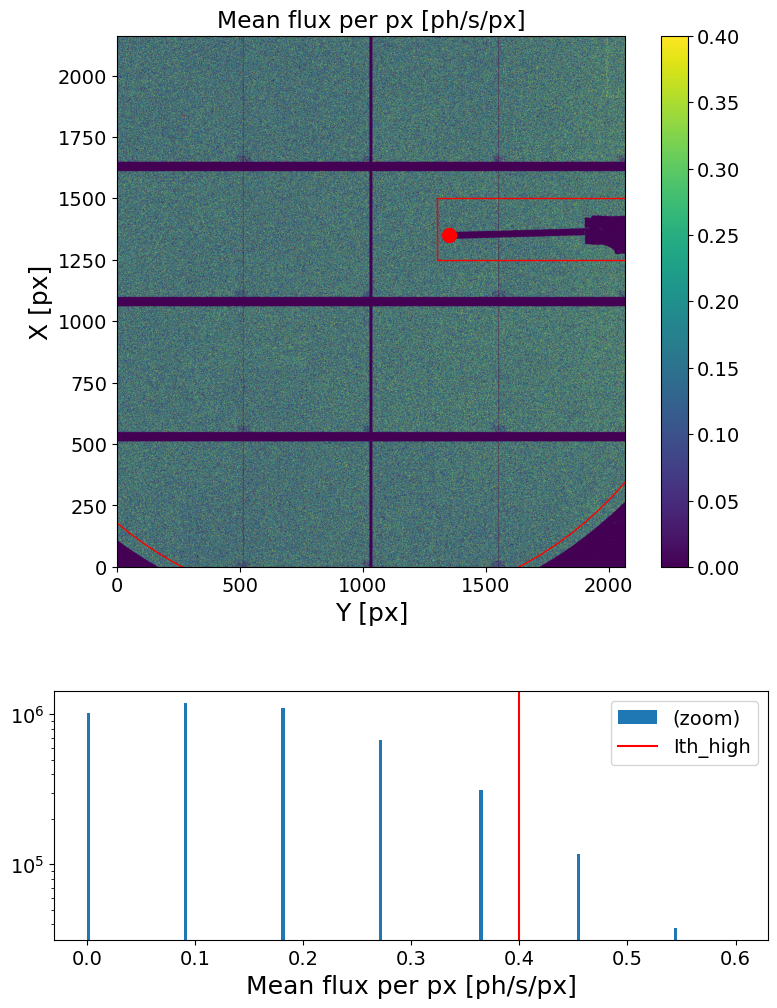

#################################################
Masked area =  93.74594052000708 %
#################################################



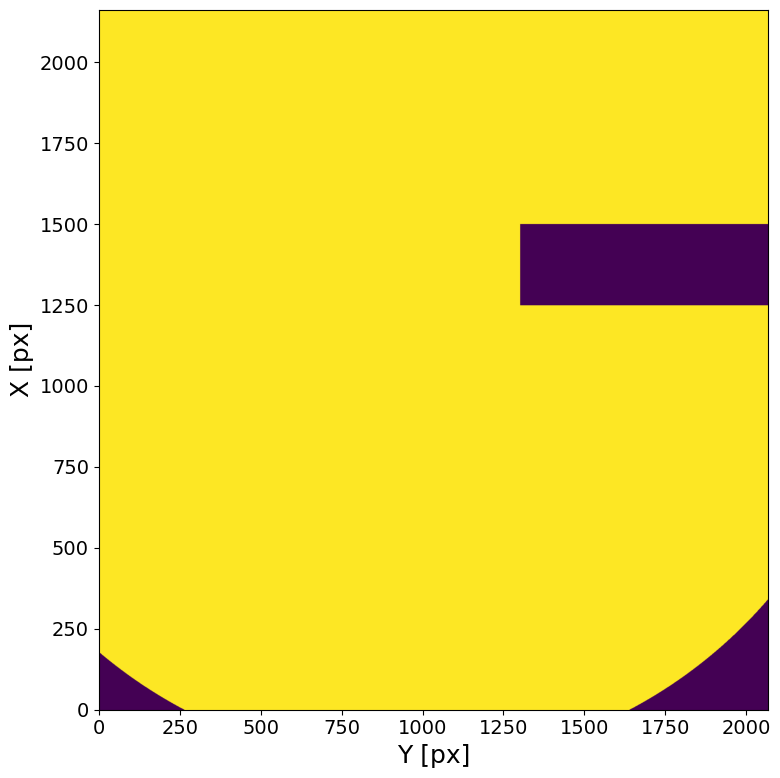

In [6]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.4, Nff=10000, mask_geom=geom,)
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Intensity analysis

In [7]:
####################
Lbin = 100
Nstep = 1000
Nfi = 15
####################

It = {}
for q in Qmask.keys():
    mask= e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    It[q] = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Nfi=Nfi, Lbin=Lbin, Nstep=Nstep))
    np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", It[q])

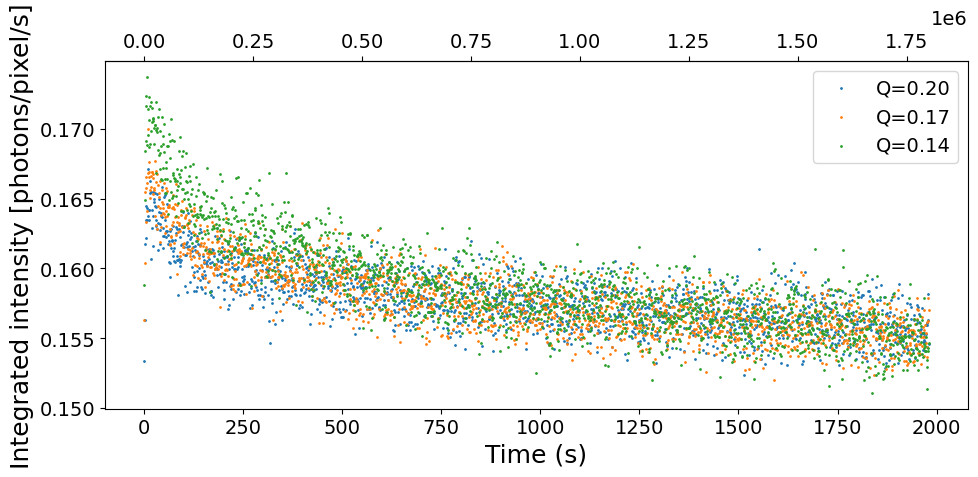

In [8]:
plt.figure(figsize=(10,5))
for q in Qmask.keys():
    plt.scatter(It[q][0], It[q][1], label='Q={:.2f}'.format(q), s=1)
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
plt.legend()
plt.tight_layout(); plt.show()

### Multitau correlation of damaged-vGeO2

In [9]:
##### INPUTS #####
Nfi = 50_000
Nff = None
sparse_depth = 12
ch_depth = 4
##################

G2tmt, g2mt = {}, {}
for q in tqdm(Qmask.keys(), desc=f'Calculating G2tmt @ q={q}'):
    mask = e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    G2tmt[q] = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=Nfi, Nff=Nff)
    g2mt[q] = np.vstack(XPCS.get_g2mt(itime, G2tmt[q]))
    np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", g2mt[q])

Calculating G2tmt @ q=0.14:   0%|          | 0/3 [00:00<?, ?it/s]

Nff set to 1798992 => (Nff-Nfi) = 427*2^sparse_depth, thrown frames = 1296 (0.07%)
Loading frames ...
Done! (elapsed time = 24.63 s)
Masking data ...
Done! (elapsed time = 78.2 s)
	 | 1748992 frames X 826633 pixels
	 | sparsity = 1.73e-04
	 | memory usage (sparse.csr_array @ float32) = 2.816 GB
Computing sparse multitau G2t...


100%|██████████| 427/427 [05:45<00:00,  1.23it/s]


Done! (elapsed time = 345.8 s)
Computing dense multitau G2t...
	-> computing channels on 3416 frames ...
	-> computing channels on 1708 frames ...
	-> computing channels on 854 frames ...
	-> computing channels on 427 frames ...
	-> computing channels on 213 frames ...
	-> computing channels on 106 frames ...
	-> computing channels on 53 frames ...
	-> computing channels on 26 frames ...
Done! (elapsed time = 100.39 s)


Calculating G2tmt @ q=0.14:  33%|███▎      | 1/3 [09:09<18:18, 549.28s/it]

...

Calculating G2tmt @ q=0.14:  67%|██████▋   | 2/3 [19:49<10:02, 602.93s/it]

Nff set to 1798992 => (Nff-Nfi) = 427*2^sparse_depth, thrown frames = 1296 (0.07%)
Loading frames ...
Done! (elapsed time = 32.22 s)
Masking data ...
Done! (elapsed time = 109.49 s)
	 | 1748992 frames X 624792 pixels
	 | sparsity = 1.74e-04
	 | memory usage (sparse.csr_array @ float32) = 2.141 GB
Computing sparse multitau G2t...


100%|██████████| 427/427 [05:38<00:00,  1.26it/s]


Done! (elapsed time = 338.24 s)
Computing dense multitau G2t...
	-> computing channels on 3416 frames ...
	-> computing channels on 1708 frames ...
	-> computing channels on 854 frames ...
	-> computing channels on 427 frames ...
	-> computing channels on 213 frames ...
	-> computing channels on 106 frames ...
	-> computing channels on 53 frames ...
	-> computing channels on 26 frames ...
Done! (elapsed time = 75.29 s)


Calculating G2tmt @ q=0.14: 100%|██████████| 3/3 [29:05<00:00, 581.84s/it]


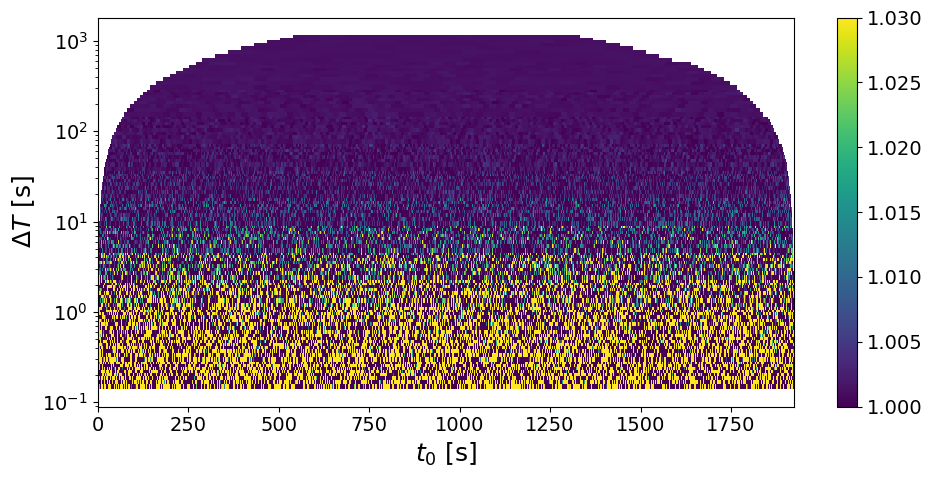

In [10]:
############################
q = .2
vmin, vmax = 1.0, 1.03
lower_corr = 4
############################

XPCS.plot_G2tmt(G2tmt[q], itime, vmin, vmax, yscale='log', lower_corr=lower_corr)

Using Global variables: model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan



,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.20,0.015,0.257826,0.026476,10.268977,0.716907,0.048823,6.810255,0.022338,0.001274,5.701372,1.001236,0.000005,0.000528,0.900172
1,0.17,0.015,0.331245,0.030305,9.148723,0.813846,0.059990,7.371182,0.020551,0.001138,5.536690,1.001183,0.000006,0.000591,1.108189
2,0.14,0.015,0.315125,0.041972,13.319045,0.647041,0.048915,7.559803,0.023585,0.001625,6.888439,1.001338,0.000007,0.000659,1.185633


Using Global variables: sample_name, Ndataset, Nscan 



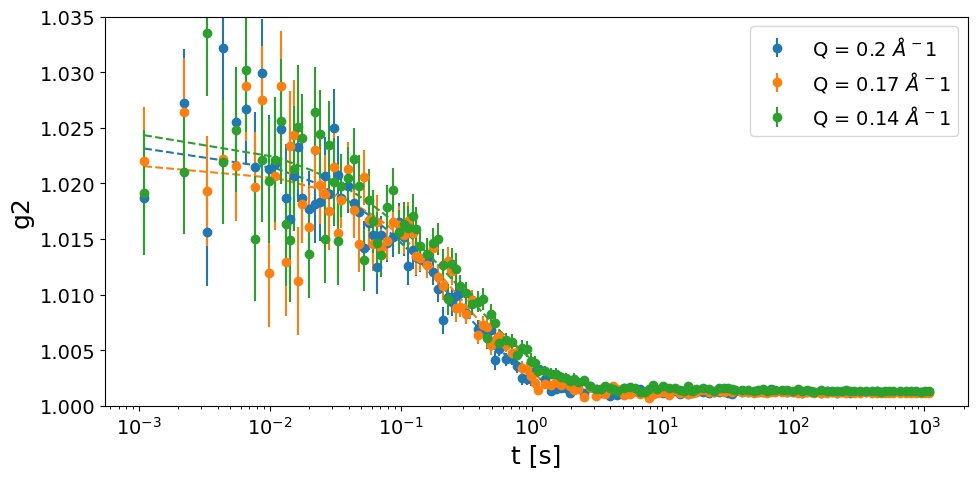

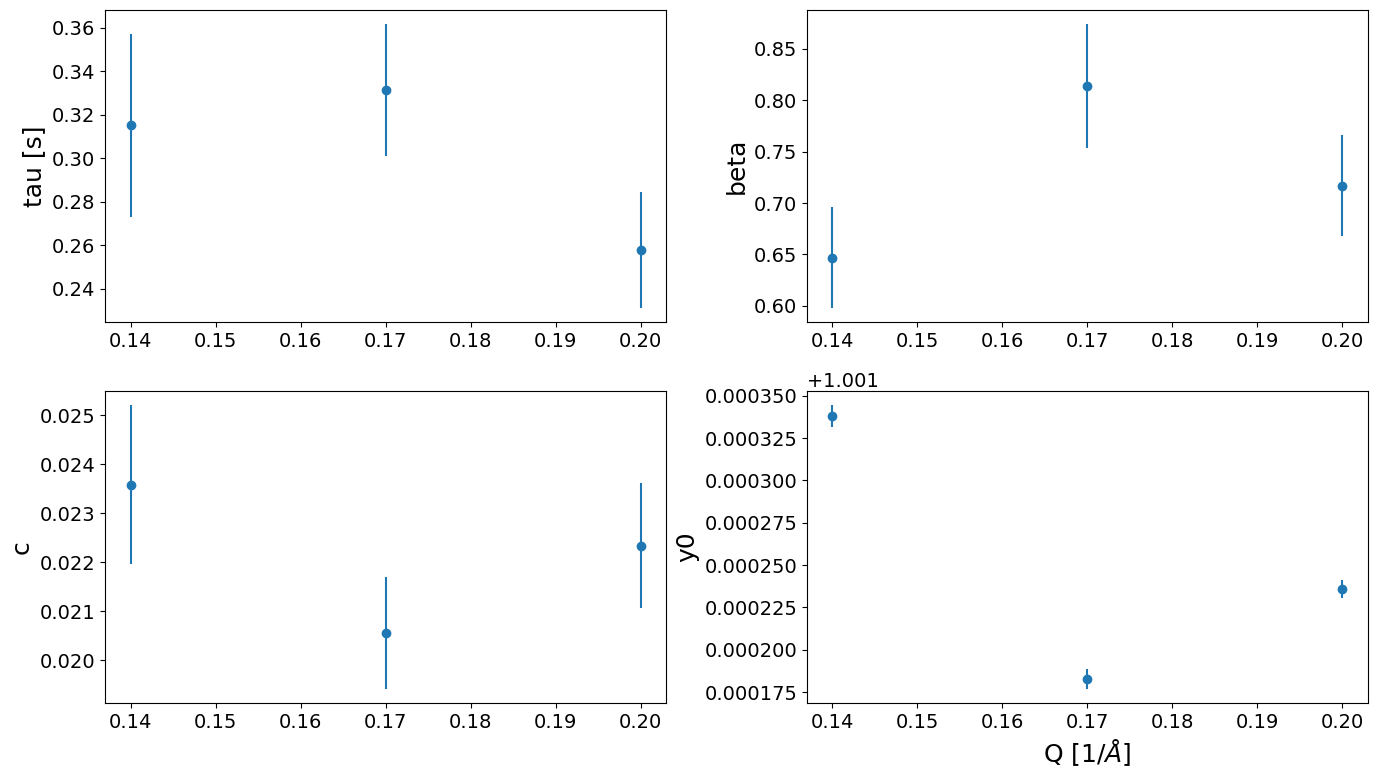

In [11]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.03)
#params.add('y0', value=1.0023, vary=False)
##############################################

g2fit, fig, ax = MTplotfit_byQ_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)
ax.set_ylim(1, 1.035)
ax.legend()
fig.tight_layout(); fig.show()

fig, axs = plotfitparams_byQ_4damaged_vGeO2(g2fit)
fig.tight_layout(); fig.show()

## XPCS scan: delcoup=1, T=730, 30min @ 1ms (GeO2_3_730C_Q, dataset 1, scan 4)

In [12]:
#######################################
sample_name = 'GeO2_3_730C_Q'
Ndataset = 1
Nscan = 4
Nfi, Nff = None, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.0000000000000004
Q = 0.09
T = 33.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h

### Qmask

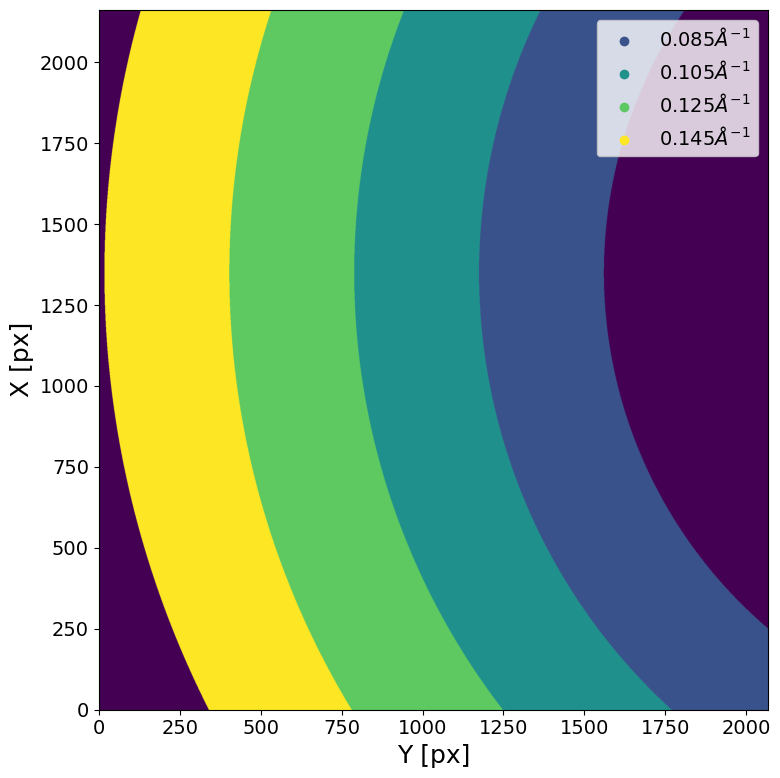

In [13]:
###################
Qs_section = [.085, .105, .125, .145,]
dQ_section = .01
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Qs_section, dQ_section, Qmap_plot=False)

### Beamstop mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  127098 pixels (of 4471016 => 2.84 %)
# of pixels below Ith_low treshold ->  761599 pixels (of 4471016 => 17.03 %)
################################################################################



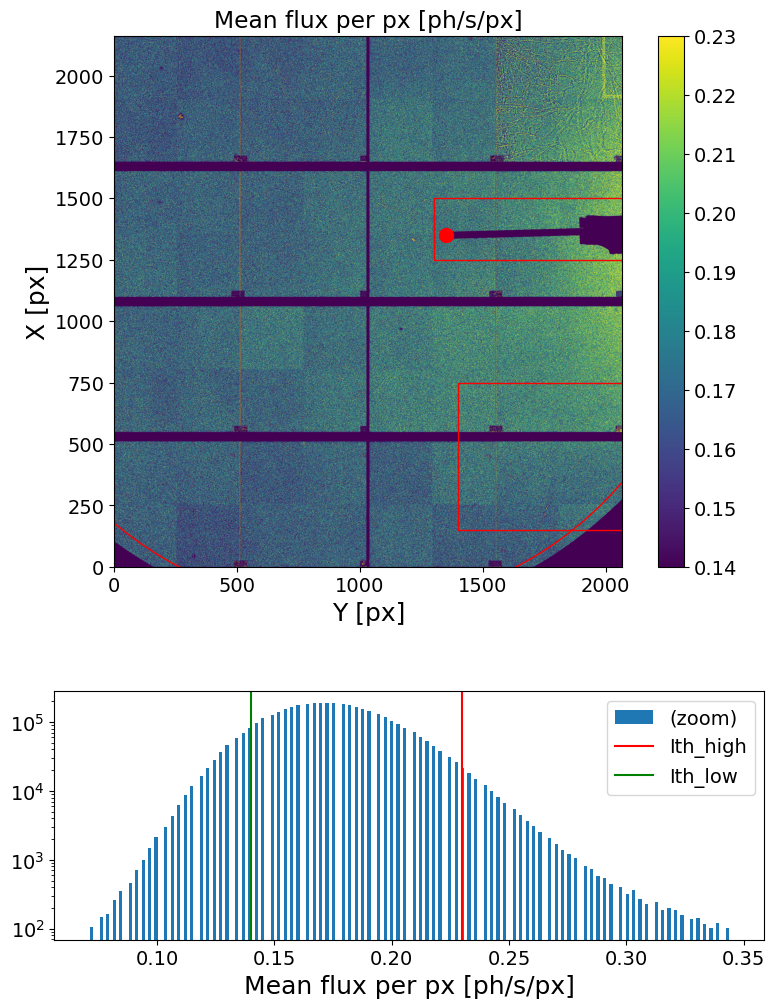

#################################################
Masked area =  85.1810863571054 %
#################################################



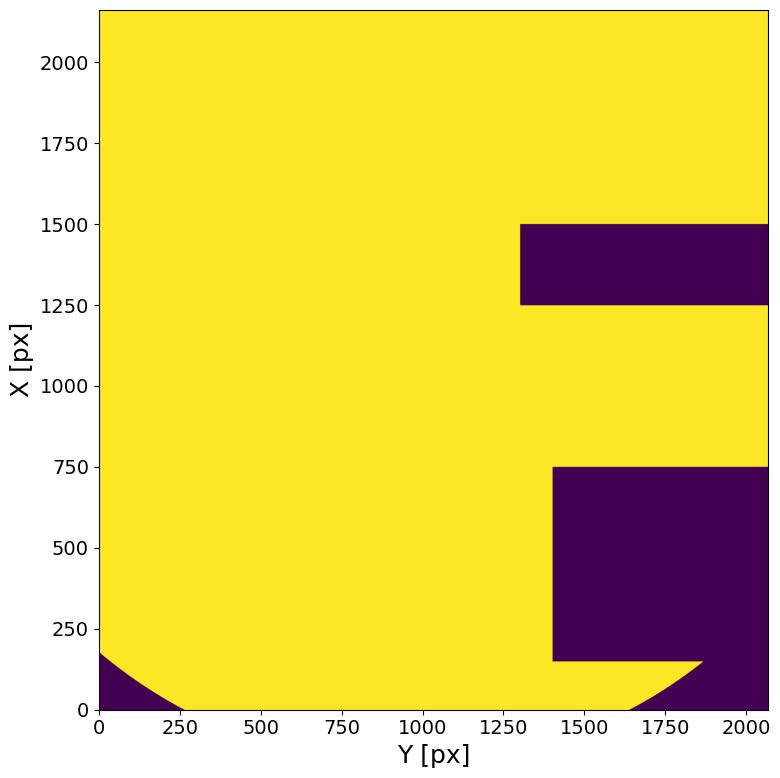

In [14]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Rectangle', 'x0':150, 'y0':1400, 'xl':600, 'yl':2000, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_low = .14, Ith_high=.23, Nff=300000, mask_geom=geom,)
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Intensity analysis

In [15]:
####################
Lbin = 100
Nstep = 1000
Nfi = 15
Nff=None
####################

It = {}
for q in Qmask.keys():
    mask= e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    It[q] = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Nfi=Nfi, Nff=Nff, Lbin=Lbin, Nstep=Nstep))
    np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", It[q])

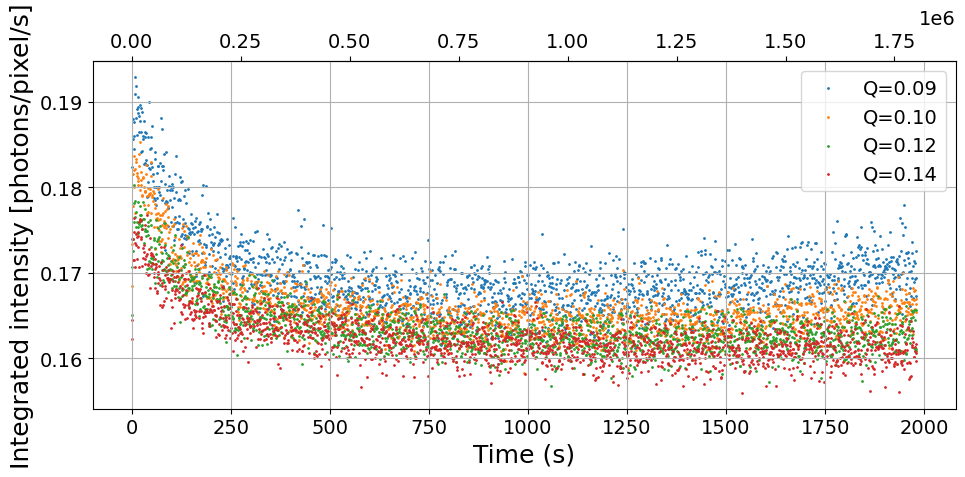

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
for q in Qmask.keys():
    ax.scatter(It[q][0], It[q][1], label='Q={:.2f}'.format(q), s=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Integrated intensity [photons/pixel/s]')
ax.secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
ax.grid()
#ax.set_xlim(0, 100)
ax.legend()
fig.tight_layout()
plt.show()

### Multitau correlation of damaged-vGeO2

In [17]:
##### INPUTS #####
Nfi = int(.5e6)
Nff = None
sparse_depth = 14
ch_depth = 4
##################

G2tmt, g2mt = {}, {}
for q in tqdm(Qmask.keys(), desc=f'Calculating G2tmt @ q={q}'):
    mask = e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    G2tmt[q] = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=Nfi, Nff=Nff)
    g2mt[q] = np.vstack(XPCS.get_g2mt(itime, G2tmt[q]))
    np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", g2mt[q])

Calculating G2tmt @ q=0.145:   0%|          | 0/4 [00:00<?, ?it/s]

Nff set to 1794336 => (Nff-Nfi) = 79*2^sparse_depth, thrown frames = 5952 (0.46%)
Loading frames ...
Done! (elapsed time = 21.92 s)
Masking data ...
Done! (elapsed time = 62.99 s)
	 | 1294336 frames X 312913 pixels
	 | sparsity = 1.85e-04
	 | memory usage (sparse.csr_array @ float32) = 0.847 GB
Computing sparse multitau G2t...


100%|██████████| 79/79 [01:25<00:00,  1.08s/it]


Done! (elapsed time = 85.49 s)
Computing dense multitau G2t...
	-> computing channels on 632 frames ...
	-> computing channels on 316 frames ...
	-> computing channels on 158 frames ...
	-> computing channels on 79 frames ...
	-> computing channels on 39 frames ...
	-> computing channels on 19 frames ...
Done! (elapsed time = 6.69 s)


Calculating G2tmt @ q=0.145:  25%|██▌       | 1/4 [02:57<08:51, 177.25s/it]

...

Calculating G2tmt @ q=0.145:  75%|███████▌  | 3/4 [07:36<02:24, 144.32s/it]

Nff set to 1794336 => (Nff-Nfi) = 79*2^sparse_depth, thrown frames = 5952 (0.46%)
Loading frames ...
Done! (elapsed time = 16.02 s)
Masking data ...
Done! (elapsed time = 56.89 s)
	 | 1294336 frames X 547875 pixels
	 | sparsity = 1.78e-04
	 | memory usage (sparse.csr_array @ float32) = 1.417 GB
Computing sparse multitau G2t...


100%|██████████| 79/79 [02:32<00:00,  1.93s/it]


Done! (elapsed time = 152.74 s)
Computing dense multitau G2t...
	-> computing channels on 632 frames ...
	-> computing channels on 316 frames ...
	-> computing channels on 158 frames ...
	-> computing channels on 79 frames ...
	-> computing channels on 39 frames ...
	-> computing channels on 19 frames ...
Done! (elapsed time = 15.69 s)


Calculating G2tmt @ q=0.145: 100%|██████████| 4/4 [11:38<00:00, 174.57s/it]


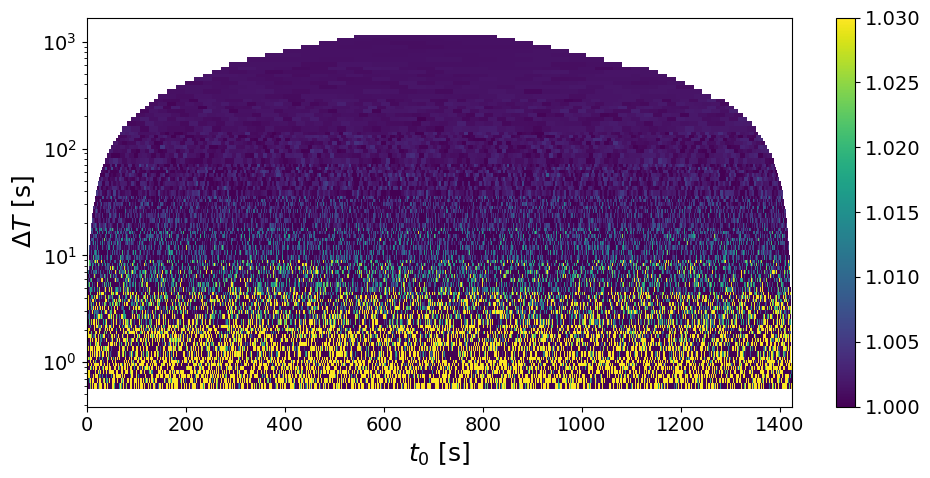

In [18]:
############################
q = .105
vmin, vmax = 1.0, 1.03
lower_corr = 6
filter_layer = 6
############################

XPCS.plot_G2tmt(G2tmt[q], itime, vmin, vmax, yscale='log', lower_corr=lower_corr, filter_layer=filter_layer)

Using Global variables: model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan



,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.085,0.01,0.333225,0.108353,32.516579,0.548185,0.078503,14.320446,0.025157,0.003784,15.041296,1.001573,0.000015,0.001476,2.258981
1,0.105,0.01,0.416502,0.058373,14.014975,0.783619,0.083742,10.686590,0.020901,0.001726,8.257725,1.001360,0.000009,0.000905,1.623914
2,0.125,0.01,0.325042,0.043833,13.485321,0.736940,0.068863,9.344383,0.022561,0.001720,7.625084,1.001245,0.000008,0.000847,1.159895
3,0.145,0.01,0.281516,0.045390,16.123420,0.674082,0.065681,9.743772,0.023424,0.002010,8.580543,1.001272,0.000008,0.000798,1.146549


Using Global variables: sample_name, Ndataset, Nscan 



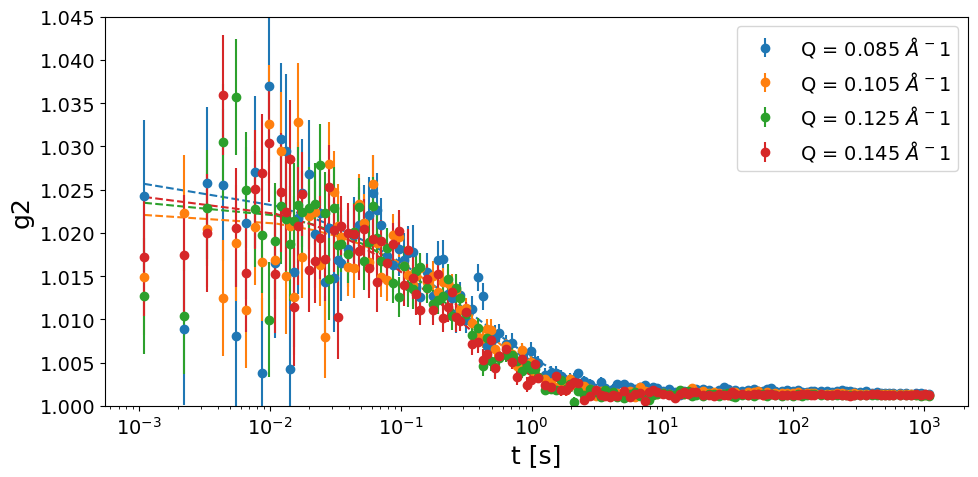

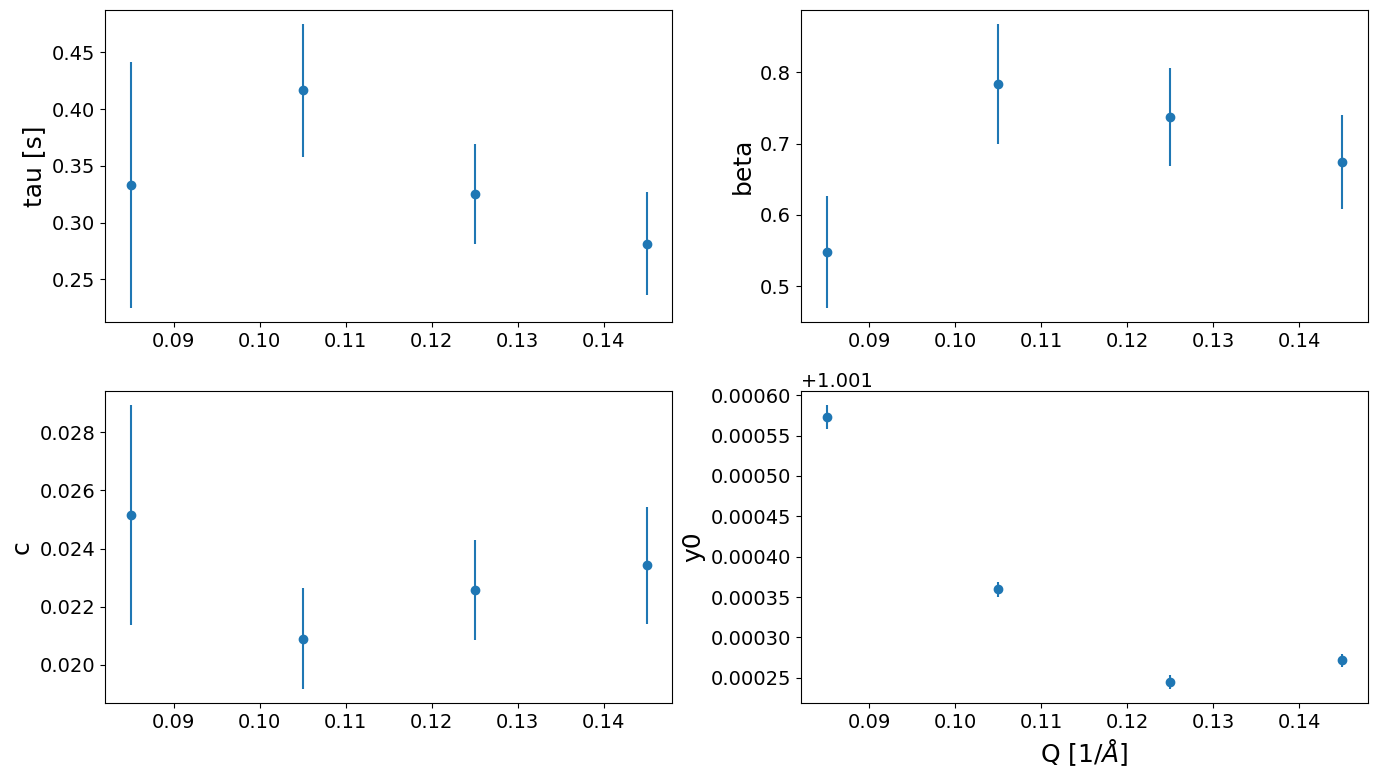

In [19]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.03)
#params.add('y0', value=1.0023, vary=False)
##############################################

g2fit, fig, ax = MTplotfit_byQ_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)
ax.set_ylim(1, 1.045)
ax.legend()
fig.tight_layout(); fig.show()

fig, axs = plotfitparams_byQ_4damaged_vGeO2(g2fit)
fig.tight_layout(); fig.show()

## XPCS scan: delcoup=3, T=730, 30min @ 1ms (GeO2_3_730C_Q, dataset 1, scan 5)

In [20]:
#######################################
sample_name = 'GeO2_3_730C_Q'
Ndataset = 1
Nscan = 5
Nfi, Nff = None, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 3.0000000000000004
Q = 0.26
T = 33.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h

### Qmask

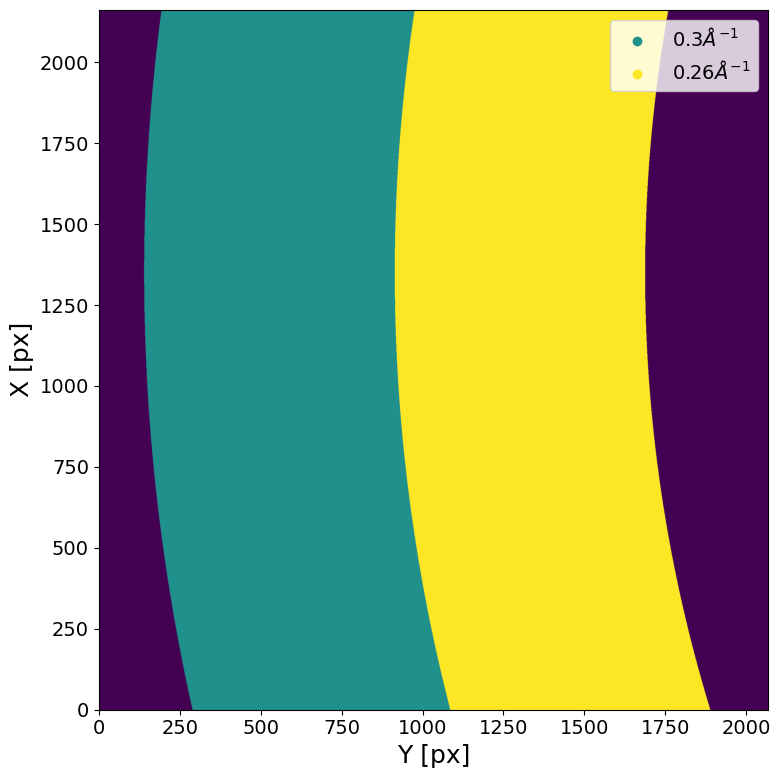

In [21]:
###################
Qs_section = [.3,.26]
dQ_section = .02
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Qs_section, dQ_section, Qmap_plot=False)

### Beamstop mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  36613 pixels (of 4471016 => 0.82 %)
# of pixels below Ith_low treshold ->  457999 pixels (of 4471016 => 10.24 %)
################################################################################



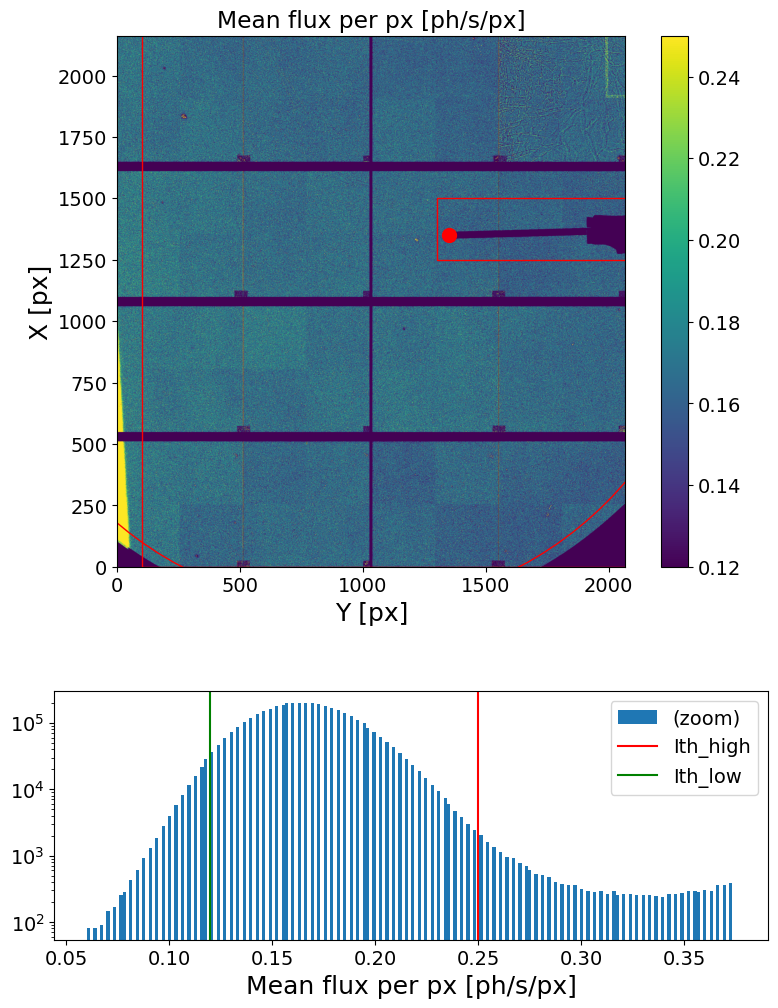

#################################################
Masked area =  89.14486103382319 %
#################################################



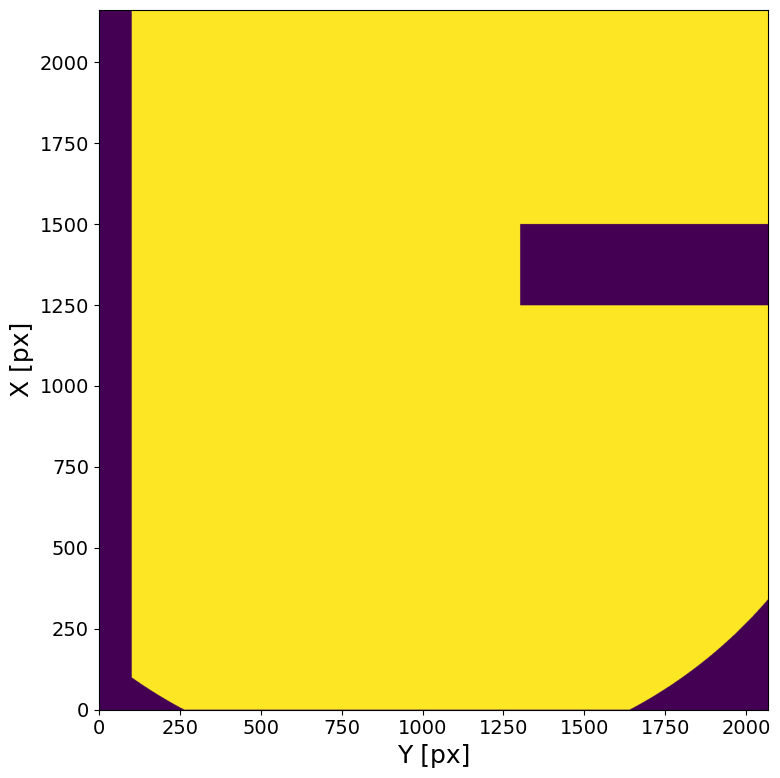

In [22]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Rectangle', 'x0':0, 'y0':100, 'xl':3000, 'yl':3000, 'inside':True},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_low = .12, Ith_high=.25, Nff=300000, mask_geom=geom,)
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Intensity analysis

In [23]:
####################
Lbin = 100
Nstep = 1000
Nfi = 15
Nff=None
####################

It = {}
for q in Qmask.keys():
    mask= e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    It[q] = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Nfi=Nfi, Nff=Nff, Lbin=Lbin, Nstep=Nstep))
    np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", It[q])

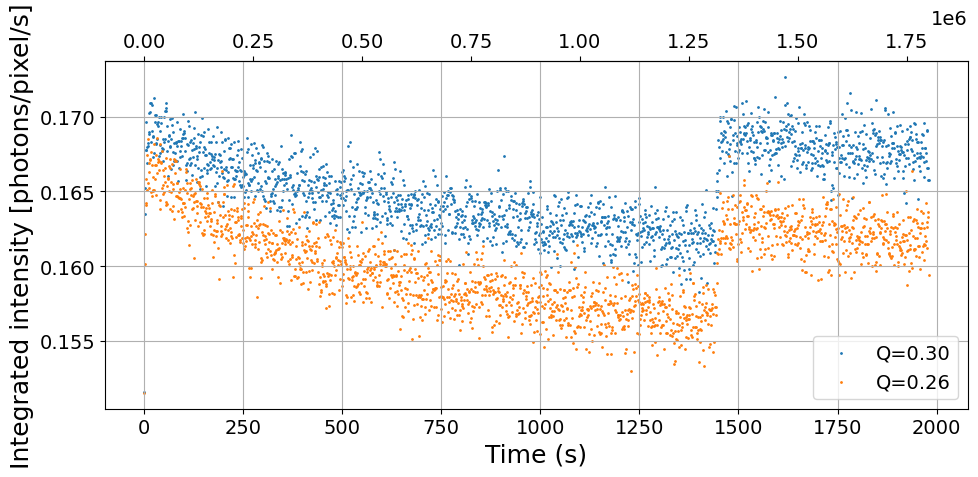

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
for q in Qmask.keys():
    ax.scatter(It[q][0], It[q][1], label='Q={:.2f}'.format(q), s=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Integrated intensity [photons/pixel/s]')
ax.secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
ax.grid()
#ax.set_xlim(0, 100)
ax.legend()
fig.tight_layout()
plt.show()

### Multitau correlation of damaged-vGeO2

In [25]:
##### INPUTS #####
Nfi = int(.5e6)
Nff = None
sparse_depth = 14
ch_depth = 4
##################

G2tmt, g2mt = {}, {}
for q in tqdm(Qmask.keys(), desc=f'Calculating G2tmt @ q={q}'):
    mask = e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    G2tmt[q] = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=Nfi, Nff=Nff)
    g2mt[q] = np.vstack(XPCS.get_g2mt(itime, G2tmt[q]))
    np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", g2mt[q])

Calculating G2tmt @ q=0.26:   0%|          | 0/2 [00:00<?, ?it/s]

Nff set to 1794336 => (Nff-Nfi) = 79*2^sparse_depth, thrown frames = 5952 (0.46%)
Loading frames ...
Done! (elapsed time = 39.77 s)
Masking data ...
Done! (elapsed time = 92.5 s)
	 | 1294336 frames X 1096545 pixels
	 | sparsity = 1.81e-04
	 | memory usage (sparse.csr_array @ float32) = 2.885 GB
Computing sparse multitau G2t...


100%|██████████| 79/79 [04:19<00:00,  3.28s/it]


Done! (elapsed time = 259.13 s)
Computing dense multitau G2t...
	-> computing channels on 632 frames ...
	-> computing channels on 316 frames ...
	-> computing channels on 158 frames ...
	-> computing channels on 79 frames ...
	-> computing channels on 39 frames ...
	-> computing channels on 19 frames ...
Done! (elapsed time = 31.4 s)


Calculating G2tmt @ q=0.26:  50%|█████     | 1/2 [07:03<07:03, 423.16s/it]

Nff set to 1794336 => (Nff-Nfi) = 79*2^sparse_depth, thrown frames = 5952 (0.46%)
Loading frames ...
Done! (elapsed time = 16.94 s)
Masking data ...
Done! (elapsed time = 44.36 s)
	 | 1294336 frames X 960467 pixels
	 | sparsity = 1.75e-04
	 | memory usage (sparse.csr_array @ float32) = 2.446 GB
Computing sparse multitau G2t...


100%|██████████| 79/79 [01:41<00:00,  1.28s/it]


Done! (elapsed time = 101.34 s)
Computing dense multitau G2t...
	-> computing channels on 632 frames ...
	-> computing channels on 316 frames ...
	-> computing channels on 158 frames ...
	-> computing channels on 79 frames ...
	-> computing channels on 39 frames ...
	-> computing channels on 19 frames ...
Done! (elapsed time = 23.76 s)


Calculating G2tmt @ q=0.26: 100%|██████████| 2/2 [10:09<00:00, 304.89s/it]


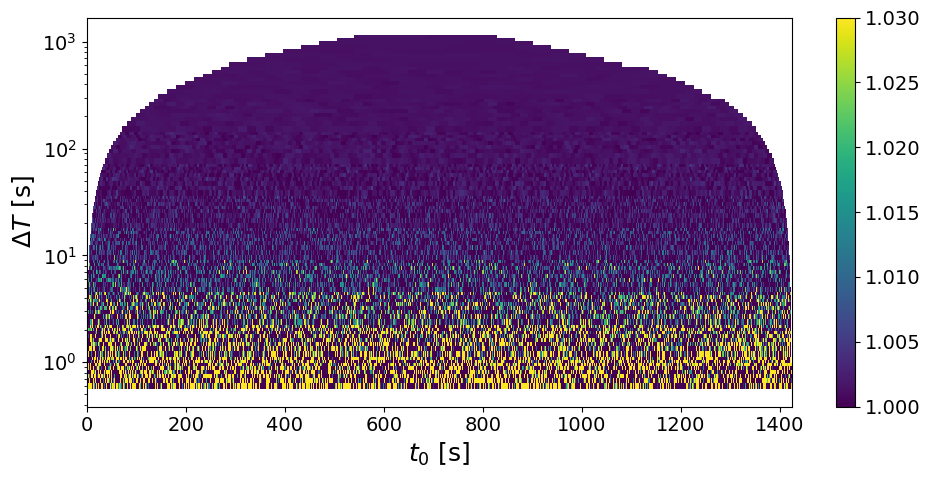

In [26]:
############################
q = .3
vmin, vmax = 1.0, 1.03
lower_corr = 6
filter_layer = 6
############################

XPCS.plot_G2tmt(G2tmt[q], itime, vmin, vmax, yscale='log', lower_corr=lower_corr, filter_layer=filter_layer)

Using Global variables: model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan



,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.30,0.02,0.235205,0.027877,11.852258,0.796214,0.073484,9.229176,0.019092,0.001351,7.073899,1.001313,0.000005,0.000518,1.155146
1,0.26,0.02,0.225997,0.023923,10.585396,0.762107,0.058748,7.708560,0.021831,0.001339,6.133972,1.001392,0.000005,0.000519,0.834683


Using Global variables: sample_name, Ndataset, Nscan 



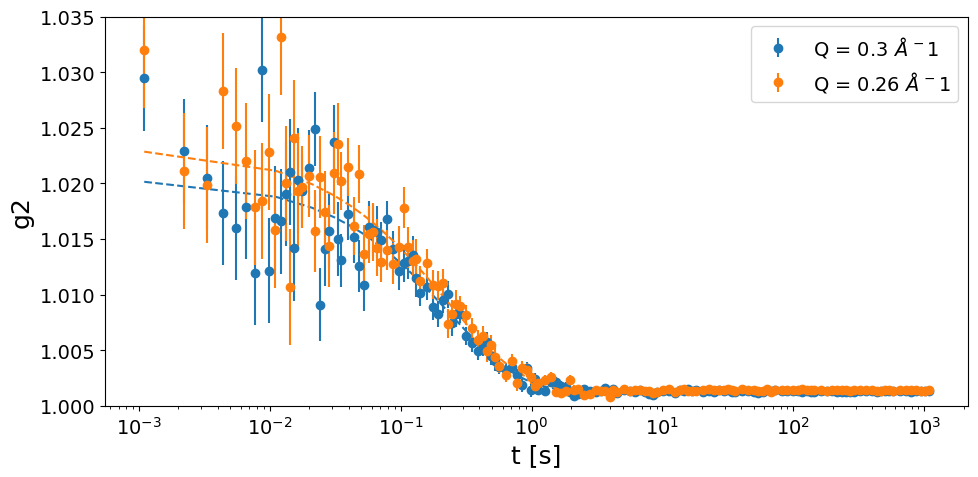

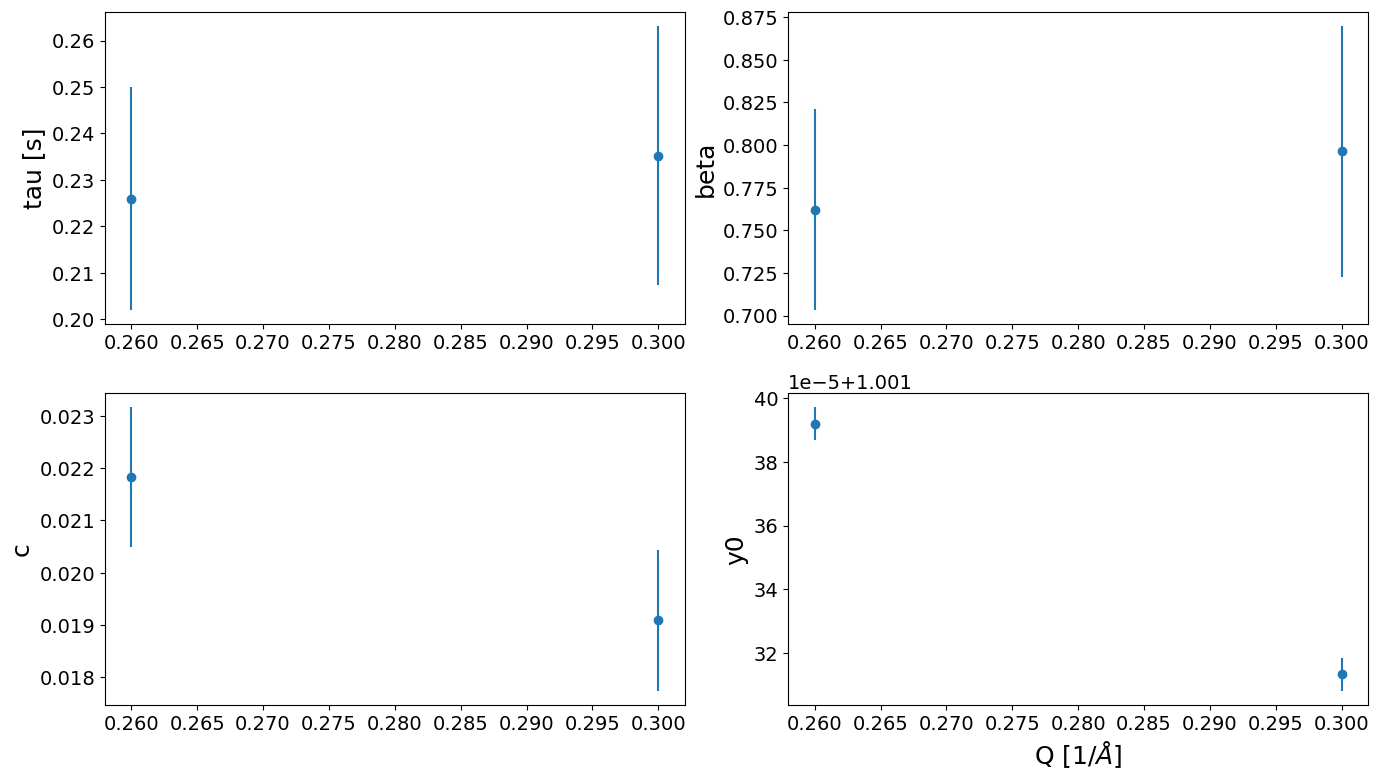

In [27]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.03)
#params.add('y0', value=1.0023, vary=False)
##############################################

g2fit, fig, ax = MTplotfit_byQ_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)
ax.set_ylim(1, 1.035)
ax.legend()
fig.tight_layout(); fig.show()

fig, axs = plotfitparams_byQ_4damaged_vGeO2(g2fit)
fig.tight_layout(); fig.show()

## XPCS scan: delcoup=4, T=730, 30min @ 1ms (GeO2_3_730C_Q, dataset 1, scan 6)

In [28]:
#######################################
sample_name = 'GeO2_3_730C_Q'
Ndataset = 1
Nscan = 6
Nfi, Nff = None, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1200192
Ei = 9.699998837562536
itime = 0.0011
theta = 4.0
Q = 0.34
T = 22.00 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/241 loops

### Qmask

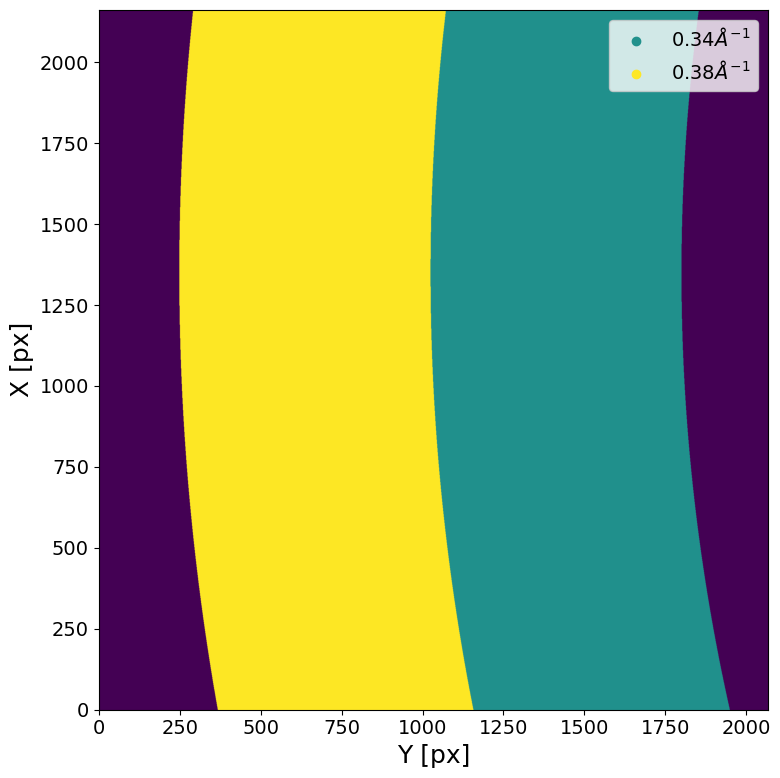

In [29]:
###################
Qs_section = [.34,.38]
dQ_section = .02
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Qs_section, dQ_section, Qmap_plot=False)

### Beamstop mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  47363 pixels (of 4471016 => 1.06 %)
# of pixels below Ith_low treshold ->  815436 pixels (of 4471016 => 18.24 %)
################################################################################



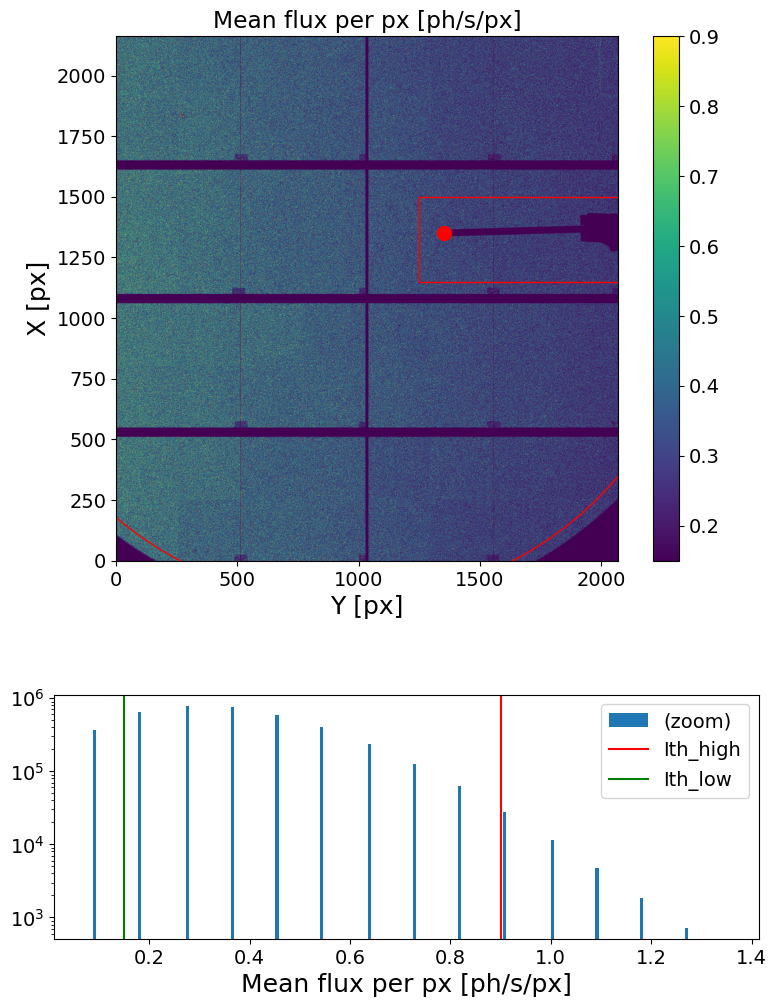

#################################################
Masked area =  91.63568191212019 %
#################################################



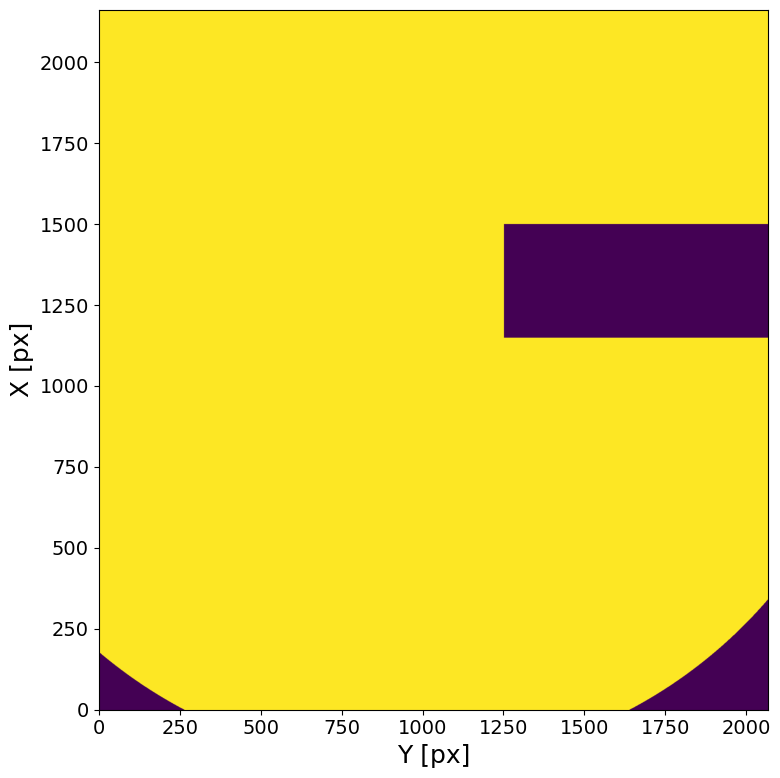

In [30]:
geom = [{'geom':'Rectangle', 'x0':1150, 'y0':1250, 'xl':350, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_low = .15, Ith_high=.9, Nff=10000, mask_geom=geom,)
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Intensity analysis

In [31]:
####################
Lbin = 10
Nstep = 100
Nfi = 15
Nff=None
####################

It = {}
for q in Qmask.keys():
    mask= e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    It[q] = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Nfi=Nfi, Nff=Nff, Lbin=Lbin, Nstep=Nstep))
    np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", It[q])

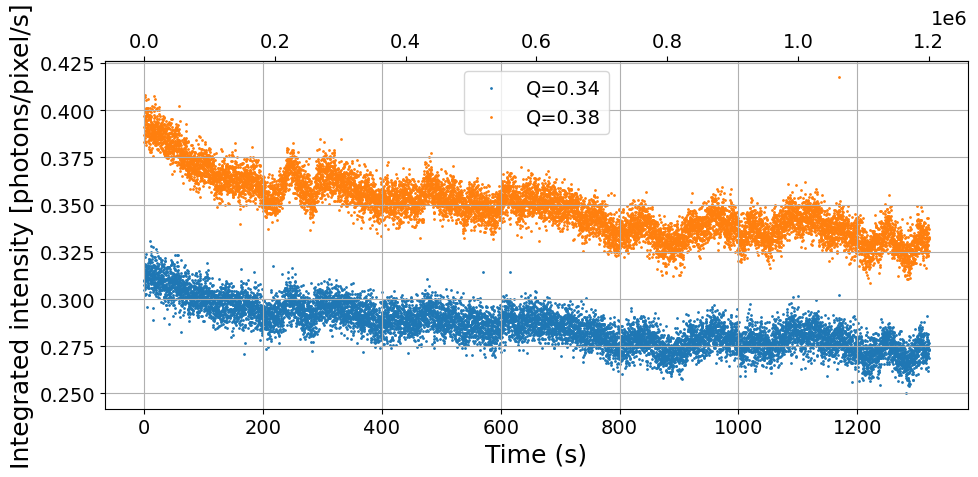

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
for q in Qmask.keys():
    ax.scatter(It[q][0], It[q][1], label='Q={:.2f}'.format(q), s=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Integrated intensity [photons/pixel/s]')
ax.secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
ax.grid()
#ax.set_xlim(0, 100)
ax.legend()
fig.tight_layout()
plt.show()

## XPCS scan: delcoup=5, T=730, 30min @ 1ms (GeO2_3_730C_Q, dataset 1, scan 7)

In [33]:
#######################################
sample_name = 'GeO2_3_730C_Q'
Ndataset = 1
Nscan = 7
Nfi, Nff = None, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1200192
Ei = 9.699998837562536
itime = 0.0011
theta = 5.0
Q = 0.43
T = 22.00 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/241 loops

### Qmask

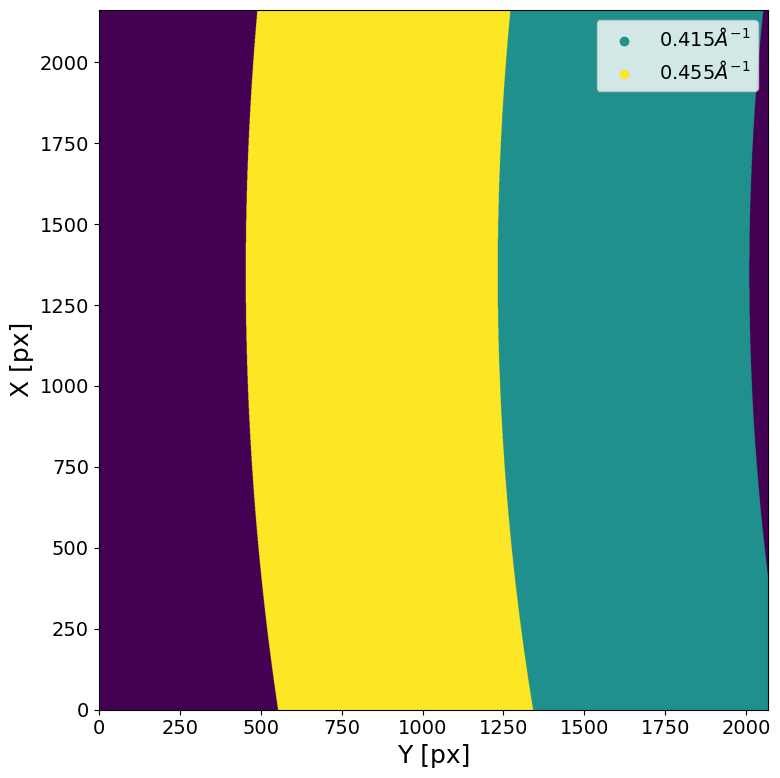

In [34]:
###################
Qs_section = [.415,.455]
dQ_section = .02
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Qs_section, dQ_section, Qmap_plot=False)

### Beamstop mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  34879 pixels (of 4471016 => 0.78 %)
# of pixels below Ith_low treshold ->  845291 pixels (of 4471016 => 18.91 %)
################################################################################



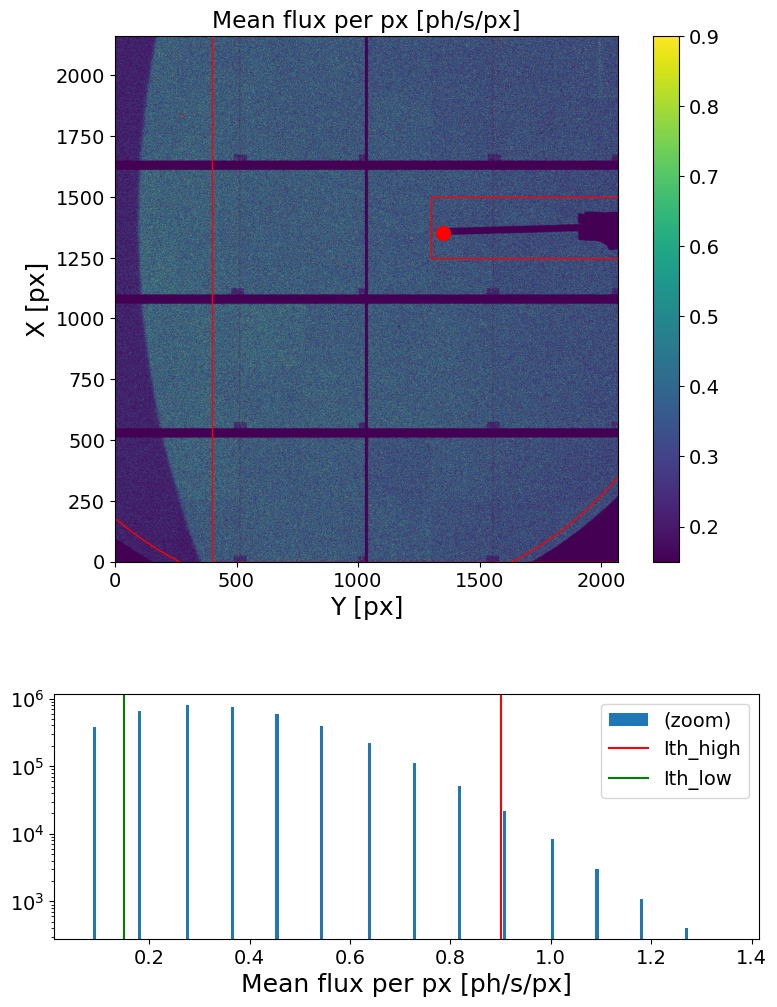

#################################################
Masked area =  74.81720038577362 %
#################################################



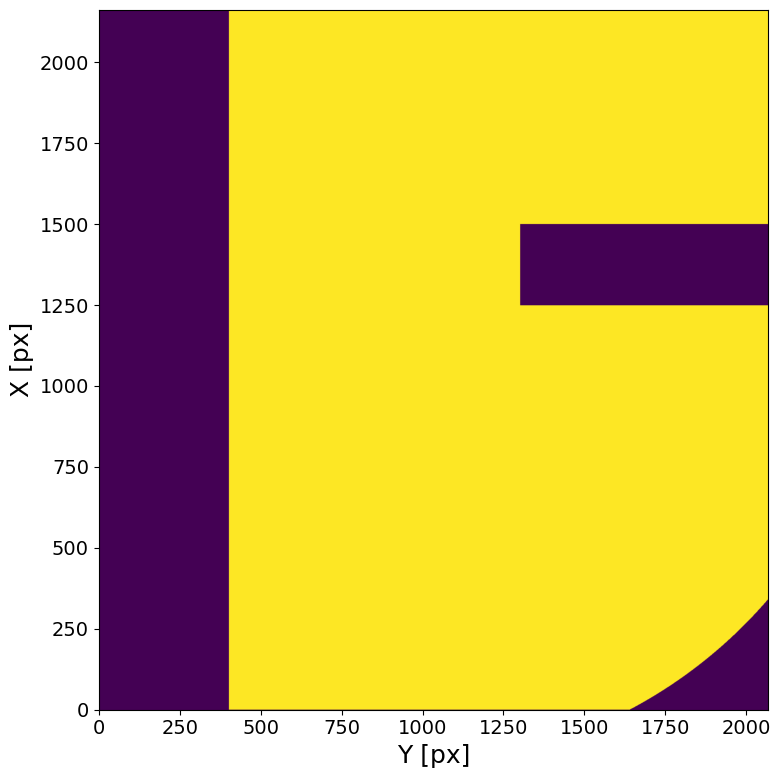

In [35]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Rectangle', 'x0':0, 'y0':400, 'xl':3000, 'yl':3000, 'inside':True},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_low = .15, Ith_high=.9, Nff=10000, mask_geom=geom,)
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Intensity analysis

In [36]:
####################
Lbin = 100
Nstep = 1000
Nfi = 15
Nff=None
####################

It = {}
for q in Qmask.keys():
    mask= e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    It[q] = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Nfi=Nfi, Nff=Nff, Lbin=Lbin, Nstep=Nstep))
    np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", It[q])

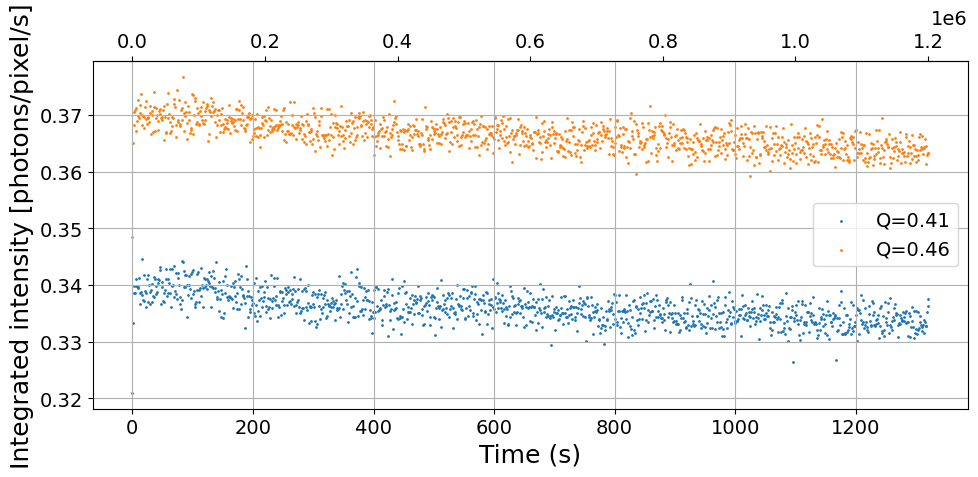

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
for q in Qmask.keys():
    ax.scatter(It[q][0], It[q][1], label='Q={:.2f}'.format(q), s=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Integrated intensity [photons/pixel/s]')
ax.secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
ax.grid()
#ax.set_xlim(0, 100)
ax.legend()
fig.tight_layout()
plt.show()

### Multitau correlation of damaged-vGeO2

In [38]:
##### INPUTS #####
Nfi = int(.5e6)
Nff = None
sparse_depth = 14
ch_depth = 4
##################

G2tmt, g2mt = {}, {}
for q in tqdm(Qmask.keys(), desc=f'Calculating G2tmt @ q={q}'):
    mask = e4m_mask * e4m_htmask * bs_mask * Qmask[q]
    G2tmt[q] = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=mask, Nfi=Nfi, Nff=Nff)
    g2mt[q] = np.vstack(XPCS.get_g2mt(itime, G2tmt[q]))
    np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={q}-dQ={dQ_section}.txt", g2mt[q])

Calculating G2tmt @ q=0.455:   0%|          | 0/2 [00:00<?, ?it/s]

Nff set to 1188128 => (Nff-Nfi) = 42*2^sparse_depth, thrown frames = 12064 (1.72%)
Loading frames ...
Done! (elapsed time = 19.27 s)
Masking data ...
Done! (elapsed time = 72.09 s)
	 | 688128 frames X 826311 pixels
	 | sparsity = 3.68e-04
	 | memory usage (sparse.csr_array @ float32) = 2.345 GB
Computing sparse multitau G2t...


100%|██████████| 42/42 [01:21<00:00,  1.93s/it]


Done! (elapsed time = 81.27 s)
Computing dense multitau G2t...
	-> computing channels on 336 frames ...
	-> computing channels on 168 frames ...
	-> computing channels on 84 frames ...
	-> computing channels on 42 frames ...
	-> computing channels on 21 frames ...
Done! (elapsed time = 10.66 s)


Calculating G2tmt @ q=0.455:  50%|█████     | 1/2 [03:03<03:03, 183.42s/it]

Nff set to 1188128 => (Nff-Nfi) = 42*2^sparse_depth, thrown frames = 12064 (1.72%)
Loading frames ...
Done! (elapsed time = 25.3 s)
Masking data ...
Done! (elapsed time = 93.83 s)
	 | 688128 frames X 1084848 pixels
	 | sparsity = 4.02e-04
	 | memory usage (sparse.csr_array @ float32) = 3.356 GB
Computing sparse multitau G2t...


100%|██████████| 42/42 [01:46<00:00,  2.54s/it]


Done! (elapsed time = 106.86 s)
Computing dense multitau G2t...
	-> computing channels on 336 frames ...
	-> computing channels on 168 frames ...
	-> computing channels on 84 frames ...
	-> computing channels on 42 frames ...
	-> computing channels on 21 frames ...
Done! (elapsed time = 11.4 s)


Calculating G2tmt @ q=0.455: 100%|██████████| 2/2 [07:00<00:00, 210.44s/it]


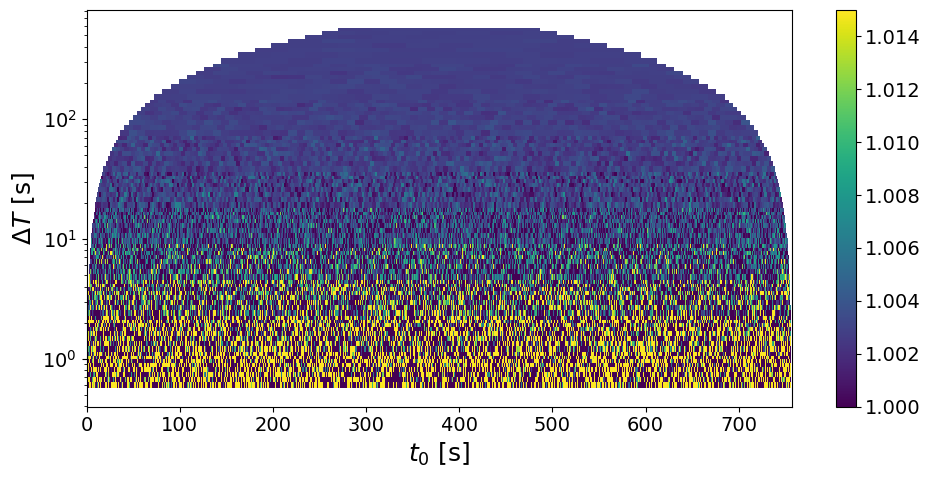

In [39]:
############################
q = 0.415
vmin, vmax = 1.0, 1.015
lower_corr = 6
filter_layer = 6
############################

XPCS.plot_G2tmt(G2tmt[q], itime, vmin, vmax, yscale='log', lower_corr=lower_corr, filter_layer=filter_layer)

Using Global variables: model, params, Qs_section, dQ_section, sample_name, Ndataset, Nscan



,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.415,0.02,0.089236,0.048653,54.522099,0.514490,0.111166,21.606954,0.008627,0.002099,24.329416,1.002821,0.000005,0.000541,0.917690
1,0.455,0.02,0.183921,0.060916,33.121018,0.728109,0.163567,22.464660,0.004979,0.000926,18.589211,1.002124,0.000005,0.000463,0.967645


Using Global variables: sample_name, Ndataset, Nscan 



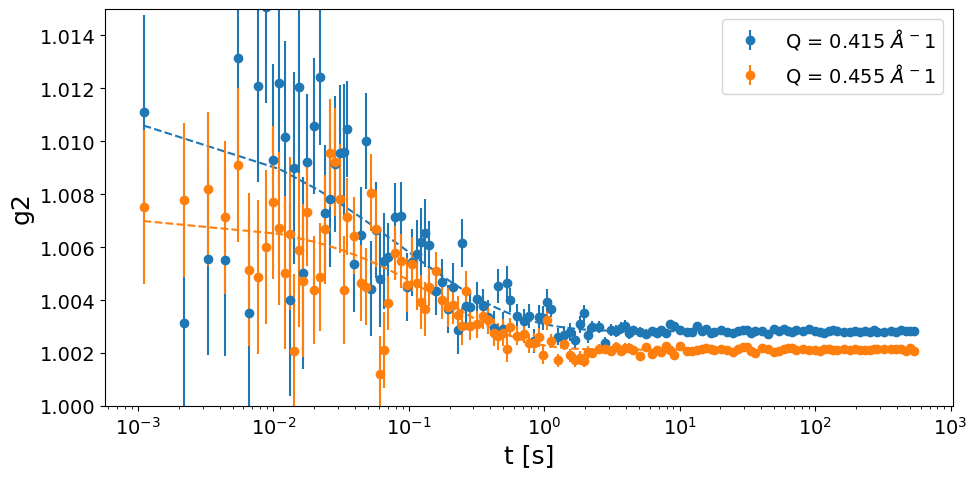

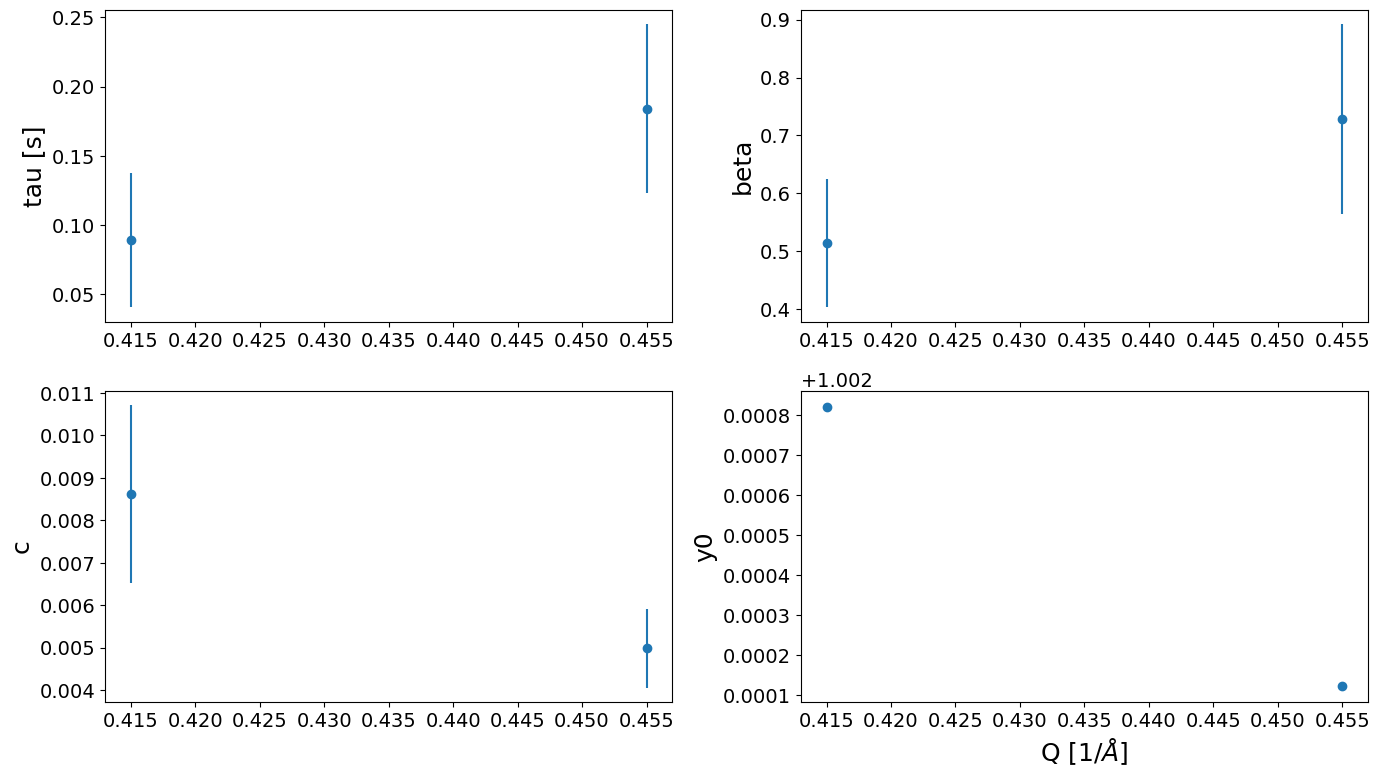

In [ ]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.03)
#params.add('y0', value=1.0023, vary=False)
##############################################

g2fit, fig, ax = MTplotfit_byQ_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=False)
ax.set_ylim(1, 1.015)
ax.legend()
fig.tight_layout(); fig.show()

fig, axs = plotfitparams_byQ_4damaged_vGeO2(g2fit)
fig.tight_layout(); fig.show()